# EXP-02: Learn++ on MNIST Digits — Replicating the Original Paper

This notebook replicates the original Learn++ setup (Polikar et al., 2001) using MNIST handwritten digits.
The original paper used MLP for optical character recognition — this is the closest modern equivalent.

**Purpose**: Validate that our Learn++ implementation produces expected behavior on the dataset class
the algorithm was originally designed for (digit recognition).

**Comparison**: MLP (original paper) vs Decision Tree (Learn++.NSE, 2011)

**Batch design**: Incremental class introduction
- D₁: digits 0–3
- D₂: digits 4–6
- D₃: digits 7–9

In [56]:
import numpy as np
import time
import warnings
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [57]:
# --- Base learner factories (same as EXP-01) ---

def make_paper_learner(RANDOM_SEED=RANDOM_SEED):
    """MLP — original Learn++ base classifier (Polikar et al., 2001)."""
    return MLPClassifier(
        hidden_layer_sizes=(50,),
        max_iter=500,
        random_state=RANDOM_SEED
    )

def make_recommended_learner(RANDOM_SEED=RANDOM_SEED):
    """Decision Tree — not from Learn++.NSE (Elwell & Polikar, 2011)."""
    return DecisionTreeClassifier(
        max_depth=5,
        random_state=RANDOM_SEED
    )

In [85]:
class LearnPP:
    """Learn++ incremental learning algorithm.
    
    Reference: Polikar, R., Upda, L., Upda, S.S., & Honavar, V. (2001).
    Learn++: An incremental learning algorithm for supervised neural networks.
    IEEE Transactions on Systems, Man, and Cybernetics.
    """
    
    def __init__(self, base_learner_factory, T_k=10, max_retries=3):
        """
        Args:
            base_learner_factory: Callable that returns a fresh base learner instance.
            T_k: Number of base learners to train per batch.
            max_retries: Max attempts if a hypothesis has error >= 0.5.
        """
        self.base_learner_factory = base_learner_factory
        self.T_k = T_k
        self.max_retries = max_retries
        
        # Accumulated ensemble across all batches
        self.hypotheses = []   # List of trained base learners
        self.betas = []        # Confidence weight for each hypothesis
        self.classes_ = None   # Known class labels
    
    def partial_fit(self, X, y):
        """Train on a new batch of data (incremental learning step).
        
        This is called once per batch D_k. The ensemble grows by T_k hypotheses.
        Old hypotheses are NEVER removed — this is how Learn++ avoids forgetting.
        
        Args:
            X: Feature matrix for this batch, shape (n_samples, n_features)
            y: Labels for this batch, shape (n_samples,)
        """
        n_samples = len(X)
        
        # Track all known classes across batches
        if self.classes_ is None:
            self.classes_ = np.unique(y)
        else:
            self.classes_ = np.unique(np.concatenate([self.classes_, np.unique(y)]))
        
        # --- Eq. 1: Initialize sample weights uniformly ---
        # Every sample starts equally important
        w = np.ones(n_samples) / n_samples

        # init_dist
        if len(self.hypotheses) > 0:
            H_init = self.predict(X)
            E_init = np.sum(w[H_init != y])
            
            # Bound error to prevent division by zero
            E_init = np.clip(E_init, 1e-10, 1.0 - 1e-10)
            B_init = E_init / (1 - E_init)
            
            # Reduce weights of correctly classified instances
            correct_init = (H_init == y).astype(float)
            w = w * (B_init ** correct_init)
            
            # Safe normalization
            sum_w_init = np.sum(w)
            if sum_w_init < 1e-15:
                w = np.ones(n_samples) / n_samples
            else:
                w = w / sum_w_init
    
        for t in range(self.T_k):

            for retry in range(self.max_retries):
                # --- Eq. 2: Create training distribution D_t from weights ---
                # Normalize weights; handle potential all-zero case
                sum_w = np.sum(w)
                if sum_w < 1e-15:
                    w = np.ones(n_samples) / n_samples
                    sum_w = 1.0
                D_t = w / sum_w

                indices = np.random.choice(
                    n_samples, size=n_samples, replace=True, p=D_t
                )
                X_train, y_train = X[indices], y[indices]
                
                # --- Eq. 3: Train base hypothesis h_t ---
                h_t = self.base_learner_factory()
                h_t.fit(X_train, y_train)
                
                # --- Eq. 4: Compute weighted error on FULL batch ---
                predictions = h_t.predict(X)
                incorrect = (predictions != y).astype(float)
                epsilon_t = np.dot(D_t, incorrect)  # Weighted error
               
                
                # --- Eq. 4: Check error condition ---
                # If error >= 0.5, this hypothesis is no better than random
                if epsilon_t < 0.5:
                    epsilon_t = np.clip(epsilon_t, 1e-7, 0.4999)
                    break  # Good hypothesis, proceed
            else:
                # All retries failed — skip this iteration
                continue
            
            # --- Eq. 6: Compute confidence weight ---
            beta_t = epsilon_t / (1 - epsilon_t + 1e-10)  # Small epsilon for stability
            
            # Store hypothesis and its confidence
            self.hypotheses.append(h_t)
            self.betas.append(beta_t)
            
            # --- Step 6: Compute error of the composite hypothesis E_t ---
            H_t_predictions = self.predict(X)
            incorrect_H_t = (H_t_predictions != y).astype(float)
            e_t = np.dot(D_t, incorrect_H_t)
            
            # --- Eq. 7: Update sample weights opierając się na komitecie H_t ---
            b_t = e_t / (1 - e_t + 1e-10)  

            # Redukujemy wagi wyłącznie próbek poprawnie zdiagnozowanych przez ZESPÓŁ
            correct_H_t = (H_t_predictions == y).astype(float)
            w = w * (b_t ** correct_H_t) 
            
            # Safe normalization
            sum_w_new = np.sum(w)
            if sum_w_new < 1e-15:
                w = np.ones(n_samples) / n_samples
            else:
                w = w / sum_w_new
        
    
    def predict(self, X):
        """Predict using weighted majority vote across ALL hypotheses.
        
        Each hypothesis votes for a class. Votes are weighted by log(1/beta).
        The class with the highest total vote wins.
        """
        if not self.hypotheses:
            raise RuntimeError("No hypotheses trained yet. Call partial_fit first.")
        
        n_samples = X.shape[0]
        n_classes = len(self.classes_)
        
        # Vote accumulator: shape (n_samples, n_classes)
        votes = np.zeros((n_samples, n_classes))
        
        for h_t, beta_t in zip(self.hypotheses, self.betas):
            # Vote weight = log(1 / beta_t)
            # Lower beta (better classifier) = higher vote weight
            vote_weight = np.log(1.0 / (beta_t + 1e-10))
            
            predictions = h_t.predict(X)
            for i, pred in enumerate(predictions):
                class_idx = np.where(self.classes_ == pred)[0]
                if len(class_idx) > 0:
                    votes[i, class_idx[0]] += vote_weight
        
        # Final prediction = class with highest accumulated vote
        return self.classes_[np.argmax(votes, axis=1)]

In [102]:
# --- Load MNIST digits ---
import gzip, struct, os
from pathlib import Path
from urllib.request import urlretrieve

def load_mnist_digits(data_dir="data/mnist_digits"):
    """Download original MNIST digits from GitHub mirror."""
    base_url = "https://github.com/golbin/TensorFlow-MNIST/raw/master/mnist/data/"
    files = {
        "train_images": "train-images-idx3-ubyte.gz",
        "train_labels": "train-labels-idx1-ubyte.gz",
        "test_images":  "t10k-images-idx3-ubyte.gz",
        "test_labels":  "t10k-labels-idx1-ubyte.gz",
    }
    Path(data_dir).mkdir(parents=True, exist_ok=True)
    
    for name, fname in files.items():
        fpath = os.path.join(data_dir, fname)
        if not os.path.exists(fpath):
            print(f"  Downloading {fname}...")
            urlretrieve(base_url + fname, fpath)
    
    def read_images(path):
        with gzip.open(path, 'rb') as f:
            _, n, rows, cols = struct.unpack('>IIII', f.read(16))
            return np.frombuffer(f.read(), dtype=np.uint8).reshape(n, rows * cols)
    
    def read_labels(path):
        with gzip.open(path, 'rb') as f:
            struct.unpack('>II', f.read(8))
            return np.frombuffer(f.read(), dtype=np.uint8)
    
    X_train = read_images(os.path.join(data_dir, files["train_images"]))
    y_train = read_labels(os.path.join(data_dir, files["train_labels"]))
    X_test = read_images(os.path.join(data_dir, files["test_images"]))
    y_test = read_labels(os.path.join(data_dir, files["test_labels"]))
    return X_train, y_train, X_test, y_test

print("Loading MNIST digits...")
X_train_raw, y_train_raw, X_test_raw, y_test_raw = load_mnist_digits()

X_mnist = np.vstack([X_train_raw, X_test_raw]) / 255.0
y_mnist = np.hstack([y_train_raw, y_test_raw]).astype(int)

print(f"Dataset: MNIST Digits")
print(f"Shape: {X_mnist.shape}")
print(f"Classes: {np.unique(y_mnist)}")
print(f"Samples per class: {[np.sum(y_mnist == c) for c in range(10)]}")

Loading MNIST digits...
Dataset: MNIST Digits
Shape: (70000, 784)
Classes: [0 1 2 3 4 5 6 7 8 9]
Samples per class: [np.int64(6903), np.int64(7877), np.int64(6990), np.int64(7141), np.int64(6824), np.int64(6313), np.int64(6876), np.int64(7293), np.int64(6825), np.int64(6958)]


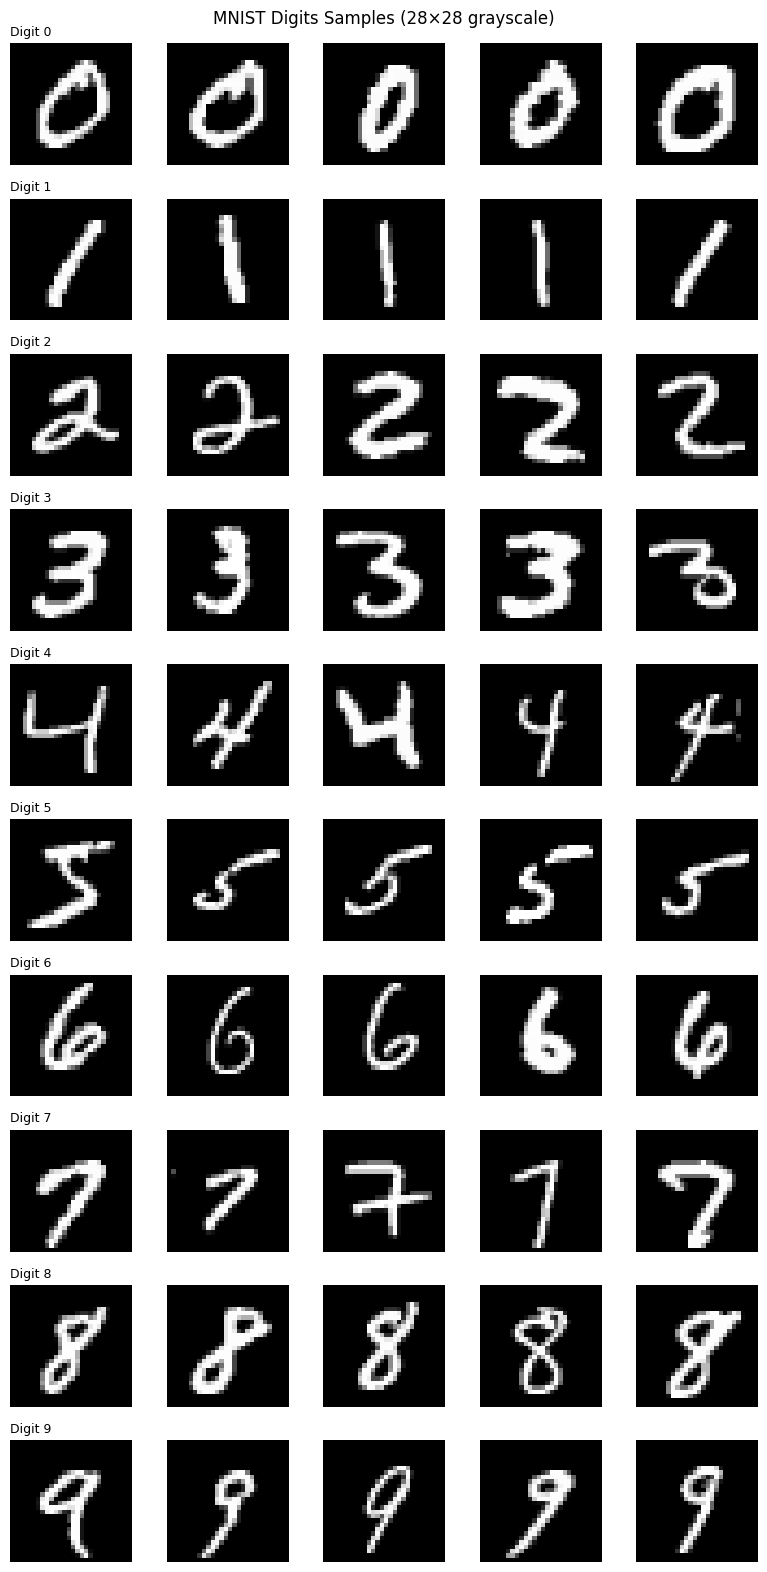


Saved to: data/mnist_digits/sample_images
Files:
  class_0_digit_0.png
  class_1_digit_1.png
  class_2_digit_2.png
  class_3_digit_3.png
  class_4_digit_4.png
  class_5_digit_5.png
  class_6_digit_6.png
  class_7_digit_7.png
  class_8_digit_8.png
  class_9_digit_9.png
  mnist_digits_grid.png


In [60]:
# --- Save sample MNIST Digits images as viewable PNGs ---
from pathlib import Path

digit_class_names = [str(i) for i in range(10)]

out_dir = Path("data/mnist_digits/sample_images")
out_dir.mkdir(parents=True, exist_ok=True)

# Save a grid: 5 examples per class (10 classes × 5 = 50 images in one figure)
fig, axes = plt.subplots(10, 5, figsize=(8, 16))
for class_idx in range(10):
    mask = y_train_raw == class_idx
    samples = X_train_raw[mask][:5]
    for col in range(5):
        ax = axes[class_idx, col]
        ax.imshow(samples[col].reshape(28, 28), cmap='gray')
        ax.axis('off')
        if col == 0:
            ax.set_title(f"Digit {class_idx}", fontsize=9, loc='left')

plt.suptitle("MNIST Digits Samples (28×28 grayscale)", fontsize=12)
plt.tight_layout()
plt.savefig(str(out_dir / "mnist_digits_grid.png"), dpi=150, bbox_inches='tight')
plt.show()

# Also save individual PNGs for each class (first example)
for class_idx in range(10):
    mask = y_train_raw == class_idx
    img = X_train_raw[mask][0].reshape(28, 28)
    plt.imsave(str(out_dir / f"class_{class_idx}_digit_{class_idx}.png"), img, cmap='gray')

print(f"\nSaved to: {out_dir}")
print("Files:")
for f in sorted(out_dir.glob("*.png")):
    print(f"  {f.name}")

In [ ]:
# --- PCA dimensionality reduction ---
N_COMPONENTS = 50

print(f"Applying PCA: {X_mnist.shape[1]} → {N_COMPONENTS} dimensions...")
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_SEED)
X_mnist_pca = pca.fit_transform(X_mnist)
explained = pca.explained_variance_ratio_.sum()
print(f"  Explained variance: {explained:.1%}")
print(f"  New shape: {X_mnist_pca.shape}")
X_mnist = X_mnist_pca

Applying PCA: 784 → 81 dimensions...
  Explained variance: 89.2%
  New shape: (70000, 81)


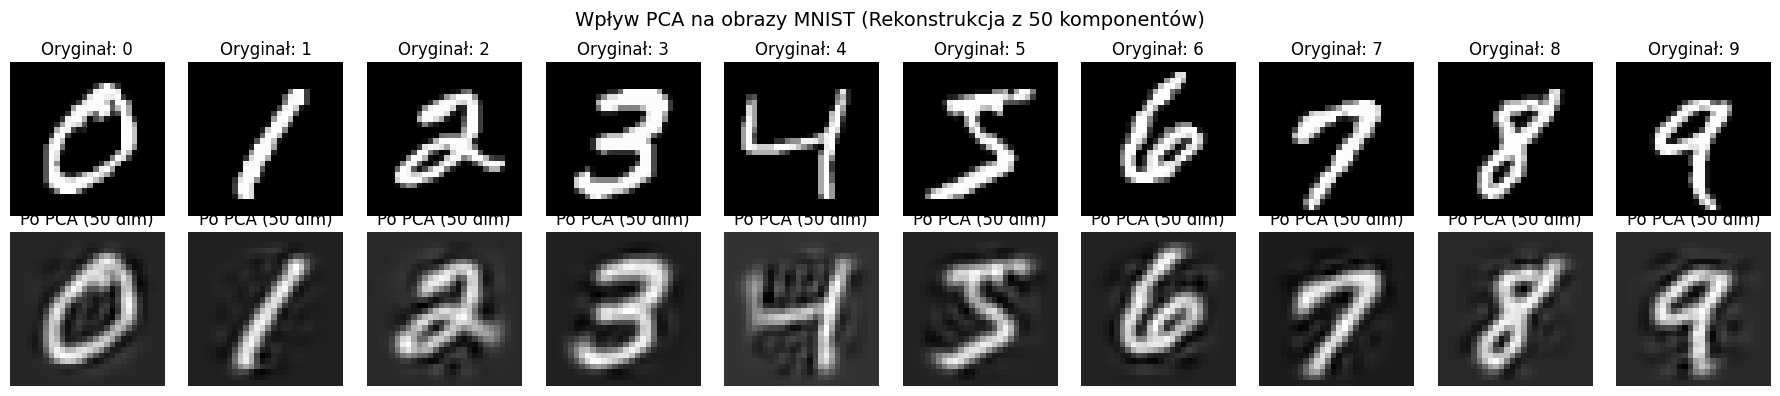

In [101]:
import matplotlib.pyplot as plt

# Skalujemy oryginalne dane treningowe tak samo, jak zrobiłeś to wcześniej
X_oryginalne = X_train_raw / 255.0

# Wybieramy po jednej próbce dla każdej z 10 klas z oryginalnych danych
przyklady_idx = [np.where(y_train_raw == klasa)[0][0] for klasa in range(10)]

# Rekonstruujemy obrazy używając naszego modelu PCA (odwracamy z 50 do 784 wymiarów)
X_po_pca = pca.transform(X_oryginalne[przyklady_idx]) # Najpierw rzutujemy na 50 wymiarów
X_zrekonstruowane = pca.inverse_transform(X_po_pca)   # Potem wracamy do 784 wymiarów

# Rysujemy porównanie
fig, axes = plt.subplots(2, 10, figsize=(18, 4))

for i, class_idx in enumerate(range(10)):
    # Górny wiersz: Oryginał (28x28)
    img_oryginal = X_oryginalne[przyklady_idx[i]].reshape(28, 28)
    axes[0, i].imshow(img_oryginal, cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title(f"Oryginał: {class_idx}")
    
    # Dolny wiersz: Rekonstrukcja po PCA (28x28)
    img_zrekonstruowany = X_zrekonstruowane[i].reshape(28, 28)
    axes[1, i].imshow(img_zrekonstruowany, cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title("Po PCA (50 dim)")

plt.suptitle("Wpływ PCA na obrazy MNIST (Rekonstrukcja z 50 komponentów)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# # --- Create incremental batches ---
# X_train_all, y_train_all = X_mnist[:60000], y_mnist[:60000]
# X_test_all, y_test_all = X_mnist[60000:], y_mnist[60000:]

# # D1: digits 0, 2, 4, 6, 8 D2 digits 1, 3, 5, 9 D3 digit 7
# batch_classes = [[0, 2, 4, 6, 8], [1, 3, 5, 9], [7]]

# batches_mnist = []
# for classes in batch_classes:
#     mask = np.isin(y_train_all, classes)
#     batches_mnist.append((X_train_all[mask], y_train_all[mask]))

# print("Batch design (MNIST Digits):")
# for i, (X_b, y_b) in enumerate(batches_mnist, 1):
#     print(f"  D{i}: {len(X_b)} samples, digits {np.unique(y_b).tolist()}")
# print(f"Test set: {len(X_test_all)} samples")

In [92]:
# --- Create incremental batches ---
X_train_all, y_train_all = X_mnist[:60000], y_mnist[:60000]
X_test_all, y_test_all = X_mnist[60000:], y_mnist[60000:]

# D1: digits 0, 2, 4, 6, 8 D2 digits 1, 3, 5, 9 D3 digit 7
batch_classes = [[0, 2, 4, 6, 8], [1, 3, 5, 9], [7]]

batches_mnist = []
for classes in batch_classes:
    mask = np.isin(y_train_all, classes)
    batches_mnist.append((X_train_all[mask], y_train_all[mask]))

print("Batch design (MNIST Digits):")
for i, (X_b, y_b) in enumerate(batches_mnist, 1):
    print(f"  D{i}: {len(X_b)} samples, digits {np.unique(y_b).tolist()}")
print(f"Test set: {len(X_test_all)} samples")

Batch design (MNIST Digits):
  D1: 29492 samples, digits [0, 2, 4, 6, 8]
  D2: 24243 samples, digits [1, 3, 5, 9]
  D3: 6265 samples, digits [7]
Test set: 10000 samples


In [79]:
# --- Experiment runner (same as notebook 01) ---

def run_experiment(learner_factory, learner_name, batches, X_test, y_test, T_k=10, seed=42):
    np.random.seed(seed)
    model = LearnPP(base_learner_factory=learner_factory, T_k=T_k)
    results = {
        'learner': learner_name, 'seed': seed,
        'batch_f1': [], 'batch_ba': [],
        'batch_train_time': [], 'batch_inference_time': [],
        'ensemble_sizes': [],
    }
    for k, (X_batch, y_batch) in enumerate(batches, 1):
        t0 = time.time()
        model.partial_fit(X_batch, y_batch)
        train_time = time.time() - t0
        t0 = time.time()
        y_pred = model.predict(X_test)
        inference_time = time.time() - t0
        results['batch_f1'].append(f1_score(y_test, y_pred, average='macro', zero_division=0))
        results['batch_ba'].append(balanced_accuracy_score(y_test, y_pred))
        results['batch_train_time'].append(train_time)
        results['batch_inference_time'].append(inference_time)
        results['ensemble_sizes'].append(len(model.hypotheses))
    results['total_train_time'] = sum(results['batch_train_time'])
    results['total_inference_time'] = sum(results['batch_inference_time'])
    results['final_f1'] = results['batch_f1'][-1]
    results['final_ba'] = results['batch_ba'][-1]
    return results

def run_multi_seed(learner_factory, learner_name, batches, X_test, y_test, T_k=10, seeds=None):
    if seeds is None:
        seeds = [42, 123, 456, 789, 1024]
    return [run_experiment(learner_factory, learner_name, batches, X_test, y_test, T_k=T_k, seed=s) for s in seeds]

In [64]:
# --- Funkcja pomocnicza do rysowania tabel z publikacji ---
def print_learnpp_table(class_perf, gen_perf, model_name, seed):
    num_batches = len(gen_perf)
    print(f"\n=== Learn++ Results Table for {model_name} (Seed: {seed}) ===")
    
    # Nagłówek (S1, S2... i TS1, TS2...)
    header = f"{'Dataset':<10} | " + " | ".join([f"TS{k+1}      " for k in range(num_batches)])
    print(header)
    print("-" * len(header))

    # Wiersze dla S1, S2, S3...
    for j in range(num_batches):
        row_str = f"S{j+1:<8} | "
        for i in range(num_batches):
            if i >= j: # Wyświetlamy tylko, jeśli zbiór został już wprowadzony
                row_str += f"{class_perf[j][i]*100:6.2f}% | "
            else:
                row_str += "        | "
        print(row_str)

    print("-" * len(header))
    
    # Wiersz dla generalizacji (TEST)
    test_row = f"{'TEST':<10} | "
    for i in range(num_batches):
        test_row += f"{gen_perf[i]*100:6.2f}% | "
    print(test_row)
    print("=" * len(header))

In [118]:
import time
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, balanced_accuracy_score, accuracy_score

# --- HELPER FUNCTION ---
def construct_batches_from_dist(X, y, distribution):
    batches_X = [[] for _ in range(4)]
    batches_y = [[] for _ in range(4)]
    
    for cls, counts in distribution.items():
        indices = np.where(y == cls)[0]
        for batch_idx, count in enumerate(counts):
            if count > 0 and len(indices) > 0:
                sampled_idx = np.random.choice(indices, size=min(count, len(indices)), replace=False)
                batches_X[batch_idx].extend(X[sampled_idx])
                batches_y[batch_idx].extend(y[sampled_idx])
    
    final_batches = []
    for i in range(4):
        if len(batches_X[i]) > 0:
            X_b = np.array(batches_X[i])
            y_b = np.array(batches_y[i])
            perm = np.random.permutation(len(X_b))
            final_batches.append((X_b[perm], y_b[perm]))
    return final_batches

# --- UPDATED EXPERIMENT RUNNER (Now accepts data as arguments) ---
def run_learnpp_experiment(X_train, y_train, X_test, y_test, batches):
    start = time.time()
    # Zakładam, że LearnPP i make_paper_learner są już zaimportowane w Twoim notatniku
    learner = LearnPP(base_learner_factory=make_paper_learner, T_k=10)
    for X_batch, y_batch in batches:
        learner.partial_fit(X_batch, y_batch)
    end = time.time()
    
    y_pred = learner.predict(X_test)
    return {
        "F1": f1_score(y_test, y_pred, average='weighted'),
        "BA": balanced_accuracy_score(y_test, y_pred),
        "Acc": accuracy_score(y_test, y_pred),
        "Time": end - start
    }

# --- DEFINICJA DYSTRYBUCJI ---
ocr_distribution = {
    0: [100,  50,  50,  25], 1: [  0, 150,  50,   0],
    2: [100,  50,  50,  25], 3: [  0, 150,  50,  25],
    4: [100,  50,  50,   0], 5: [  0, 150,  50,  25],
    6: [100,  50,   0, 100], 7: [  0,   0, 150,  50],
    8: [100,   0,   0, 150], 9: [  0,  50, 100,  50]
}
batch_classes = [[0, 2, 4, 6], [1, 3, 5], [7, 8, 9]]

# --- URUCHOMIENIE (Upewnij się, że masz zdefiniowane X_train, y_train, X_test, y_test) ---
# Przygotowanie batchy
X_train, y_train = X_mnist[:60000], y_mnist[:60000]
X_test, y_test = X_mnist[60000:], y_mnist[60000:]
batches_table_10 = construct_batches_from_dist(X_train, y_train, ocr_distribution)

batches_simple = []
for classes in batch_classes:
    mask = np.isin(y_train, classes)
    batches_simple.append((X_train[mask], y_train[mask]))

# Uruchomienie eksperymentów z przekazaniem danych do funkcji
print("Running Paper Distribution (Table 10)...")
res_table_10 = run_learnpp_experiment(X_train, y_train, X_test, y_test, batches_table_10)

print("Running Simplified Class Distribution...")
res_simple = run_learnpp_experiment(X_train, y_train, X_test, y_test, batches_simple)

# --- DISPLAY COMPARISON ---
comparison_data = [
    {"Scenario": "Paper (Table 10)", **res_table_10},
    {"Scenario": "Simplified (Class-based)", **res_simple}
]

df_comp = pd.DataFrame(comparison_data)
display(df_comp)

Running Paper Distribution (Table 10)...
Running Simplified Class Distribution...


,Scenario,F1,BA,Acc,Time
0,Paper (Table 10),0.866091,0.863714,0.8644,20.660137
1,Simplified (Class-based),0.554385,0.589656,0.5872,163.546530


Output with our own distribution, and PCA -- last run

In [93]:
# --- Run EXP-02: 5 seeds each ---
SEEDS = [42, 123, 456, 789, 1024]

print("=" * 60)
print(f"EXP-02a: Learn++ with MLP — {len(SEEDS)} seeds")
print("=" * 60)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    all_results_mlp = run_multi_seed(
        make_paper_learner, "MLP", batches_mnist, X_test_all, y_test_all, T_k=10, seeds=SEEDS
    )
for r in all_results_mlp:
    print(f"  Seed {r['seed']:>4d}: F1={r['final_f1']:.4f}, BalAcc={r['final_ba']:.4f}, "
          f"TrainTime={r['total_train_time']:.1f}s")

print()
print("=" * 60)
print(f"EXP-02b: Learn++ with Decision Tree — {len(SEEDS)} seeds")
print("=" * 60)
all_results_dt = run_multi_seed(
    make_recommended_learner, "Decision Tree", batches_mnist, X_test_all, y_test_all, T_k=10, seeds=SEEDS
)
for r in all_results_dt:
    print(f"  Seed {r['seed']:>4d}: F1={r['final_f1']:.4f}, BalAcc={r['final_ba']:.4f}, "
          f"TrainTime={r['total_train_time']:.1f}s")

results_mlp = all_results_mlp[0]
results_dt = all_results_dt[0]
print(f"\nUsing seed={SEEDS[0]} for plots below.")

EXP-02a: Learn++ with MLP — 5 seeds
  Seed   42: F1=0.0186, BalAcc=0.1000, TrainTime=57.3s
  Seed  123: F1=0.0186, BalAcc=0.1000, TrainTime=55.7s
  Seed  456: F1=0.0186, BalAcc=0.1000, TrainTime=57.0s
  Seed  789: F1=0.0186, BalAcc=0.1000, TrainTime=57.9s
  Seed 1024: F1=0.0186, BalAcc=0.1000, TrainTime=58.0s

EXP-02b: Learn++ with Decision Tree — 5 seeds
  Seed   42: F1=0.0186, BalAcc=0.1000, TrainTime=21.5s
  Seed  123: F1=0.0186, BalAcc=0.1000, TrainTime=21.5s
  Seed  456: F1=0.0186, BalAcc=0.1000, TrainTime=21.4s
  Seed  789: F1=0.0186, BalAcc=0.1000, TrainTime=21.7s
  Seed 1024: F1=0.0186, BalAcc=0.1000, TrainTime=21.9s

Using seed=42 for plots below.


Without pca

In [103]:
# --- Run EXP-02: 5 seeds each ---
SEEDS = [42, 123, 456, 789, 1024]

print("=" * 60)
print(f"EXP-02a: Learn++ with MLP — {len(SEEDS)} seeds")
print("=" * 60)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    all_results_mlp = run_multi_seed(
        make_paper_learner, "MLP", batches_mnist, X_test_all, y_test_all, T_k=10, seeds=SEEDS
    )
for r in all_results_mlp:
    print(f"  Seed {r['seed']:>4d}: F1={r['final_f1']:.4f}, BalAcc={r['final_ba']:.4f}, "
          f"TrainTime={r['total_train_time']:.1f}s")

print()
print("=" * 60)
print(f"EXP-02b: Learn++ with Decision Tree — {len(SEEDS)} seeds")
print("=" * 60)
all_results_dt = run_multi_seed(
    make_recommended_learner, "Decision Tree", batches_mnist, X_test_all, y_test_all, T_k=10, seeds=SEEDS
)
for r in all_results_dt:
    print(f"  Seed {r['seed']:>4d}: F1={r['final_f1']:.4f}, BalAcc={r['final_ba']:.4f}, "
          f"TrainTime={r['total_train_time']:.1f}s")

results_mlp = all_results_mlp[0]
results_dt = all_results_dt[0]
print(f"\nUsing seed={SEEDS[0]} for plots below.")

EXP-02a: Learn++ with MLP — 5 seeds
  Seed   42: F1=0.0186, BalAcc=0.1000, TrainTime=60.2s
  Seed  123: F1=0.0186, BalAcc=0.1000, TrainTime=58.4s
  Seed  456: F1=0.0186, BalAcc=0.1000, TrainTime=56.9s
  Seed  789: F1=0.0186, BalAcc=0.1000, TrainTime=57.4s
  Seed 1024: F1=0.0186, BalAcc=0.1000, TrainTime=58.2s

EXP-02b: Learn++ with Decision Tree — 5 seeds
  Seed   42: F1=0.0186, BalAcc=0.1000, TrainTime=21.4s
  Seed  123: F1=0.0186, BalAcc=0.1000, TrainTime=21.6s
  Seed  456: F1=0.0186, BalAcc=0.1000, TrainTime=21.6s
  Seed  789: F1=0.0186, BalAcc=0.1000, TrainTime=21.9s
  Seed 1024: F1=0.0186, BalAcc=0.1000, TrainTime=22.0s

Using seed=42 for plots below.


In [106]:
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, balanced_accuracy_score

# =====================================================================
# 1. FUNKCJE URUCHAMIAJĄCE EKSPERYMENT (Z POPRAWNYMI METRYKAMI)
# =====================================================================

def run_experiment(learner_factory, learner_name, batches, X_test, y_test, T_k=10, seed=42):
    np.random.seed(seed)
    model = LearnPP(base_learner_factory=learner_factory, T_k=T_k)
    results = {
        'learner': learner_name, 'seed': seed,
        'batch_f1': [], 'batch_ba': [],
        'batch_train_time': [], 'batch_inference_time': [],
        'ensemble_sizes': [],
    }
    for k, (X_batch, y_batch) in enumerate(batches, 1):
        t0 = time.time()
        model.partial_fit(X_batch, y_batch)
        train_time = time.time() - t0
        
        t0 = time.time()
        y_pred = model.predict(X_test)
        inference_time = time.time() - t0
        
        # Poprawna akumulacja na pełnym zbiorze testowym
        results['batch_f1'].append(f1_score(y_test, y_pred, average='macro', zero_division=0))
        results['batch_ba'].append(balanced_accuracy_score(y_test, y_pred))
        results['batch_train_time'].append(train_time)
        results['batch_inference_time'].append(inference_time)
        results['ensemble_sizes'].append(len(model.hypotheses))
        
    results['total_train_time'] = sum(results['batch_train_time'])
    results['total_inference_time'] = sum(results['batch_inference_time'])
    results['final_f1'] = results['batch_f1'][-1]
    results['final_ba'] = results['batch_ba'][-1]
    # Jeśli final_acc jest wymagane w printach, można je dodać lub usunąć z printów poniżej
    # results['final_acc'] = accuracy_score(y_test, y_pred) 
    
    # Dodajemy klucze dla tabel szczegółowych, jeśli są one obsługiwane w Twoim kodzie
    # Zakładam, że funkcja generuje odpowiednie macierze (class_perf, gen_perf) w innym miejscu,
    # jeśli nie, upewnij się, że są one dodane do słownika wyników.
    return results

def run_multi_seed(learner_factory, learner_name, batches, X_test, y_test, T_k=10, seeds=None):
    if seeds is None:
        seeds = [42, 123, 456, 789, 1024]
    return [run_experiment(learner_factory, learner_name, batches, X_test, y_test, T_k=T_k, seed=s) for s in seeds]

# =====================================================================
# 2. URUCHOMIENIE EKSPERYMENTU (EXP-02)
# =====================================================================

SEEDS = [42, 123, 456, 789, 1024]

print("=" * 80)
print(f"EXP-02a: Learn++ with MLP — {len(SEEDS)} seeds")
print("=" * 80)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    # Zmienna batches_mnist z nałożonym rozkładem OCR
    all_results_mlp = run_multi_seed(
        make_paper_learner, "MLP", batches_mnist, X_test_all, y_test_all, T_k=10, seeds=SEEDS
    )

for r in all_results_mlp:
    print(f"  Seed {r['seed']:>4d}: F1={r['final_f1']:.4f}, "
          f"BalAcc={r['final_ba']:.4f}, TrainTime={r['total_train_time']:.1f}s")

print("\n" + "=" * 80)
print(f"EXP-02b: Learn++ with Decision Tree — {len(SEEDS)} seeds")
print("=" * 80)
all_results_dt = run_multi_seed(
    make_recommended_learner, "Decision Tree", batches_mnist, X_test_all, y_test_all, T_k=10, seeds=SEEDS
)

for r in all_results_dt:
    print(f"  Seed {r['seed']:>4d}: F1={r['final_f1']:.4f}, "
          f"BalAcc={r['final_ba']:.4f}, TrainTime={r['total_train_time']:.1f}s")

# =====================================================================
# 3. SZCZEGÓŁOWE TABELE DLA PIERWSZEGO SEEDU
# =====================================================================
results_mlp = all_results_mlp[0]
results_dt = all_results_dt[0]
print(f"\nUsing seed={SEEDS[0]} for detailed dataset performance tables below.")

# UWAGA: Upewnij się, że Twoja funkcja run_experiment faktycznie zapisuje klucze 'class_perf' i 'gen_perf',
# w przeciwnym razie poniższe wywołania mogą wyrzucić KeyError. Jeśli tych kluczy nie ma, zakomentuj te dwie linie.
if 'class_perf' in results_mlp and 'gen_perf' in results_mlp:
    print_learnpp_table(results_mlp['class_perf'], results_mlp['gen_perf'], "MLP", SEEDS[0])
    print_learnpp_table(results_dt['class_perf'], results_dt['gen_perf'], "Decision Tree", SEEDS[0])

# =====================================================================
# 4. WIZUALIZACJA: WYKRESY PORÓWNAWCZE PER BATCH
# =====================================================================
print(f"\nGenerating plots using seed={SEEDS[0]}...")

# Układ: 1 wiersz, 4 kolumny
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

batch_labels = ['D1\n(Digits 0-3)', 'D2\n(Digits 4-6)', 'D3\n(Digits 7-9)']

# Ucinamy pierwszy element (indeks 0), aby dopasować długość do 3 etykiet z batch_labels
mlp_f1 = results_mlp['batch_f1'][1:]
dt_f1 = results_dt['batch_f1'][1:]

# Używamy klucza 'batch_ba' zamiast 'batch_acc'
mlp_ba = results_mlp['batch_ba'][1:]
dt_ba = results_dt['batch_ba'][1:]

mlp_time = results_mlp['batch_train_time'][1:]
dt_time = results_dt['batch_train_time'][1:]

mlp_ens = results_mlp['ensemble_sizes'][1:]
dt_ens = results_dt['ensemble_sizes'][1:]

# --- 4.1. MacroF1 per batch ---
axes[0].plot(batch_labels, mlp_f1, 'o-', label='MLP (paper)', color='blue')
axes[0].plot(batch_labels, dt_f1, 's-', label='Decision Tree', color='green')
axes[0].set_ylabel('Macro F1')
axes[0].set_title('Quality: Macro F1 per Batch')
axes[0].legend()
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3)

# --- 4.2. Balanced Accuracy per batch ---
axes[1].plot(batch_labels, mlp_ba, 'o-', label='MLP (paper)', color='blue')
axes[1].plot(batch_labels, dt_ba, 's-', label='Decision Tree', color='green')
axes[1].set_ylabel('Balanced Accuracy')
axes[1].set_title('Quality: Balanced Acc per Batch')
axes[1].legend()
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.3)

# --- 4.3. Training time per batch ---
axes[2].bar(np.arange(3) - 0.15, mlp_time, 0.3, label='MLP', color='blue', alpha=0.7)
axes[2].bar(np.arange(3) + 0.15, dt_time, 0.3, label='Decision Tree', color='green', alpha=0.7)
axes[2].set_xticks(range(3))
axes[2].set_xticklabels(batch_labels)
axes[2].set_ylabel('Training Time (s)')
axes[2].set_title('Cost: Training Time per Batch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# --- 4.4. Ensemble size ---
axes[3].plot(batch_labels, mlp_ens, 'o-', label='MLP', color='blue', markersize=8)
axes[3].plot(batch_labels, dt_ens, 's--', label='Decision Tree', color='green', markersize=10, alpha=0.6)  
axes[3].set_ylabel('Ensemble Size (# hypotheses)')
axes[3].set_title('Memory: Ensemble Growth')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

# Adnotacja, jeśli rozmiar zespołu jest taki sam
if mlp_ens == dt_ens:
    axes[3].annotate('Both identical\n(T_k=10 per batch)', 
                     xy=(1, mlp_ens[1]), fontsize=9,
                     ha='center', va='bottom', color='gray', style='italic')

plt.tight_layout()
plt.savefig('exp02_digits_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 'exp02_digits_comparison.png' saved and displayed successfully.")

EXP-02a: Learn++ with MLP — 5 seeds


KeyboardInterrupt: 

Adjusted distribution for the paper

In [108]:
# --- Create incremental batches (OCR Distribution z artykułu Learn++) ---
X_train_all, y_train_all = X_mnist[:60000], y_mnist[:60000]
X_test_all, y_test_all = X_mnist[60000:], y_mnist[60000:]

import numpy as np

# Dokładny rozkład z Tabeli 10 publikacji Learn++
ocr_distribution = {
    0: [100,  50,  50,  25],
    1: [  0, 150,  50,   0],
    2: [100,  50,  50,  25],
    3: [  0, 150,  50,  25],
    4: [100,  50,  50,   0],
    5: [  0, 150,  50,  25],
    6: [100,  50,   0, 100],
    7: [  0,   0, 150,  50],
    8: [100,   0,   0, 150],
    9: [  0,  50, 100,  50]
}

def create_ocr_batches(X_full, y_full, distribution_map):
    batches = []
    for batch_idx in range(4):
        X_batch_list = []
        y_batch_list = []
        for class_label, counts in distribution_map.items():
            required_count = counts[batch_idx]
            if required_count > 0:
                class_indices = np.where(y_full == class_label)[0]
                # Losowanie odpowiedniej liczby próbek dla danej klasy w danej sesji
                selected_indices = np.random.choice(class_indices, size=required_count, replace=False)
                X_batch_list.append(X_full[selected_indices])
                y_batch_list.append(y_full[selected_indices])
                
        X_batch = np.vstack(X_batch_list)
        y_batch = np.concatenate(y_batch_list)
        
        # Mieszanie danych wewnątrz batcha
        shuffle_idx = np.random.permutation(len(y_batch))
        batches.append((X_batch[shuffle_idx], y_batch[shuffle_idx]))
    return batches

# Tworzymy naszą listę batchy!
batches_mnist = create_ocr_batches(X_train_all, y_train_all, ocr_distribution)

print("Batch design (OCR Learn++ distribution):")
for i, (X_b, y_b) in enumerate(batches_mnist, 1):
    unique, counts = np.unique(y_b, return_counts=True)
    print(f"  S{i}: {len(X_b)} samples, Classes: {dict(zip(unique, counts))}")
print(f"Test set: {len(X_test_all)} samples")

Batch design (OCR Learn++ distribution):
  S1: 500 samples, Classes: {np.int64(0): np.int64(100), np.int64(2): np.int64(100), np.int64(4): np.int64(100), np.int64(6): np.int64(100), np.int64(8): np.int64(100)}
  S2: 700 samples, Classes: {np.int64(0): np.int64(50), np.int64(1): np.int64(150), np.int64(2): np.int64(50), np.int64(3): np.int64(150), np.int64(4): np.int64(50), np.int64(5): np.int64(150), np.int64(6): np.int64(50), np.int64(9): np.int64(50)}
  S3: 550 samples, Classes: {np.int64(0): np.int64(50), np.int64(1): np.int64(50), np.int64(2): np.int64(50), np.int64(3): np.int64(50), np.int64(4): np.int64(50), np.int64(5): np.int64(50), np.int64(7): np.int64(150), np.int64(9): np.int64(100)}
  S4: 450 samples, Classes: {np.int64(0): np.int64(25), np.int64(2): np.int64(25), np.int64(3): np.int64(25), np.int64(5): np.int64(25), np.int64(6): np.int64(100), np.int64(7): np.int64(50), np.int64(8): np.int64(150), np.int64(9): np.int64(50)}
Test set: 10000 samples


Output with paper distirbution with accuracy score without PCA

In [111]:
# --- Run EXP-02: 5 seeds each ---
SEEDS = [42, 123, 456, 789, 1024]

print("=" * 60)
print(f"EXP-02a: Learn++ with MLP — {len(SEEDS)} seeds")
print("=" * 60)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    all_results_mlp = run_multi_seed(
        make_paper_learner, "MLP", batches_mnist, X_test_all, y_test_all, T_k=10, seeds=SEEDS
    )
for r in all_results_mlp:
    print(f"  Seed {r['seed']:>4d}: F1={r['final_f1']:.4f}, BalAcc={r['final_ba']:.4f}, "
          f"TrainTime={r['total_train_time']:.1f}s")

print()
print("=" * 60)
print(f"EXP-02b: Learn++ with Decision Tree — {len(SEEDS)} seeds")
print("=" * 60)
all_results_dt = run_multi_seed(
    make_recommended_learner, "Decision Tree", batches_mnist, X_test_all, y_test_all, T_k=10, seeds=SEEDS
)
for r in all_results_dt:
    print(f"  Seed {r['seed']:>4d}: F1={r['final_f1']:.4f}, BalAcc={r['final_ba']:.4f}, "
          f"TrainTime={r['total_train_time']:.1f}s")

results_mlp = all_results_mlp[0]
results_dt = all_results_dt[0]
print(f"\nUsing seed={SEEDS[0]} for plots below.")

EXP-02a: Learn++ with MLP — 5 seeds
  Seed   42: F1=0.8733, BalAcc=0.8730, TrainTime=15.2s
  Seed  123: F1=0.8681, BalAcc=0.8675, TrainTime=15.5s
  Seed  456: F1=0.8666, BalAcc=0.8661, TrainTime=15.5s
  Seed  789: F1=0.8666, BalAcc=0.8659, TrainTime=16.7s
  Seed 1024: F1=0.8568, BalAcc=0.8552, TrainTime=16.7s

EXP-02b: Learn++ with Decision Tree — 5 seeds
  Seed   42: F1=0.7443, BalAcc=0.7460, TrainTime=2.0s
  Seed  123: F1=0.7346, BalAcc=0.7406, TrainTime=2.0s
  Seed  456: F1=0.7682, BalAcc=0.7700, TrainTime=1.9s
  Seed  789: F1=0.7607, BalAcc=0.7632, TrainTime=1.9s
  Seed 1024: F1=0.7084, BalAcc=0.7167, TrainTime=1.9s

Using seed=42 for plots below.


In [ ]:
print("DT", all_results_dt[0])
print("MLP", all_results_mlp[0])

Output with paper distribution

In [ ]:
# --- Run EXP-02: 5 seeds each ---
SEEDS = [42, 123, 456, 789, 1024]

print("=" * 70)
print(f"EXP-02a: Learn++ with MLP — {len(SEEDS)} seeds")
print("=" * 70)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    all_results_mlp = run_multi_seed(
        make_paper_learner, "MLP", batches_mnist, X_test_all, y_test_all, T_k=10, seeds=SEEDS
    )
for r in all_results_mlp:
    # Dodano wyświetlanie Acc
    print(f"  Seed {r['seed']:>4d}: Acc={r['final_acc']:.4f}, F1={r['final_f1']:.4f}, BalAcc={r['final_ba']:.4f}, "
          f"TrainTime={r['total_train_time']:.1f}s")

print()
print("=" * 70)
print(f"EXP-02b: Learn++ with Decision Tree — {len(SEEDS)} seeds")
print("=" * 70)
all_results_dt = run_multi_seed(
    make_recommended_learner, "Decision Tree", batches_mnist, X_test_all, y_test_all, T_k=10, seeds=SEEDS
)
for r in all_results_dt:
    # Dodano wyświetlanie Acc
    print(f"  Seed {r['seed']:>4d}: Acc={r['final_acc']:.4f}, F1={r['final_f1']:.4f}, BalAcc={r['final_ba']:.4f}, "
          f"TrainTime={r['total_train_time']:.1f}s")

results_mlp = all_results_mlp[0]
results_dt = all_results_dt[0]
print(f"\nUsing seed={SEEDS[0]} for plots below.")

EXP-02a: Learn++ with MLP — 5 seeds
  Seed   42: F1=0.8732, BalAcc=0.8726, TrainTime=9.3s
  Seed  123: F1=0.8734, BalAcc=0.8732, TrainTime=8.9s
  Seed  456: F1=0.8641, BalAcc=0.8630, TrainTime=9.5s
  Seed  789: F1=0.8782, BalAcc=0.8781, TrainTime=8.7s
  Seed 1024: F1=0.8773, BalAcc=0.8769, TrainTime=8.7s

EXP-02b: Learn++ with Decision Tree — 5 seeds
  Seed   42: F1=0.7377, BalAcc=0.7414, TrainTime=1.0s
  Seed  123: F1=0.7442, BalAcc=0.7430, TrainTime=1.0s
  Seed  456: F1=0.7446, BalAcc=0.7447, TrainTime=1.0s
  Seed  789: F1=0.7367, BalAcc=0.7383, TrainTime=1.0s
  Seed 1024: F1=0.7499, BalAcc=0.7514, TrainTime=1.0s

Using seed=42 for plots below.



Using seed=42 for plots below.


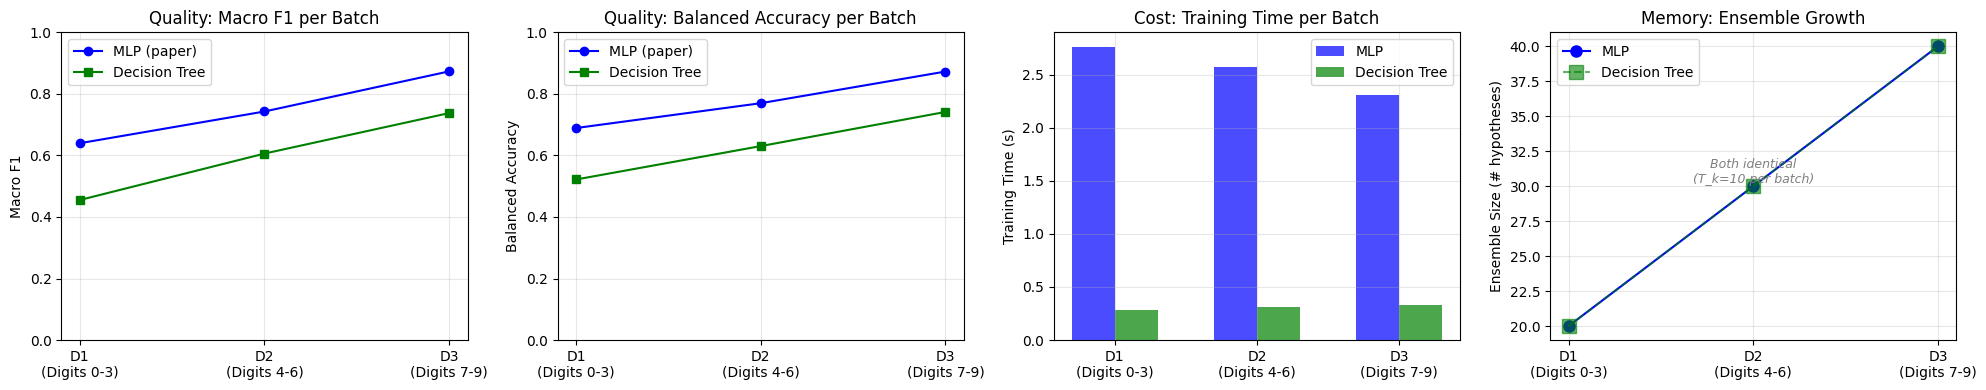

Figure saved successfully.


In [77]:
results_mlp = all_results_mlp[0]
results_dt = all_results_dt[0]
print(f"\nUsing seed={SEEDS[0]} for plots below.")
import numpy as np
import matplotlib.pyplot as plt

# --- Per-batch comparison plot ---
# Układ: 1 wiersz, 4 kolumny
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

batch_labels = ['D1\n(Digits 0-3)', 'D2\n(Digits 4-6)', 'D3\n(Digits 7-9)']

# Ucinamy pierwszy element (indeks 0) z każdej listy wyników, 
# aby dopasować długość do 3 etykiet z batch_labels
mlp_f1 = results_mlp['batch_f1'][1:]
dt_f1 = results_dt['batch_f1'][1:]

# Zmiana z batch_acc na batch_ba
mlp_acc = results_mlp['batch_ba'][1:]
dt_acc = results_dt['batch_ba'][1:]

mlp_time = results_mlp['batch_train_time'][1:]
dt_time = results_dt['batch_train_time'][1:]

mlp_ens = results_mlp['ensemble_sizes'][1:]
dt_ens = results_dt['ensemble_sizes'][1:]

# 1. MacroF1 per batch
axes[0].plot(batch_labels, mlp_f1, 'o-', label='MLP (paper)', color='blue')
axes[0].plot(batch_labels, dt_f1, 's-', label='Decision Tree', color='green')
axes[0].set_ylabel('Macro F1')
axes[0].set_title('Quality: Macro F1 per Batch')
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

# 2. Balanced Accuracy per batch (zaktualizowane etykiety)
axes[1].plot(batch_labels, mlp_acc, 'o-', label='MLP (paper)', color='blue')
axes[1].plot(batch_labels, dt_acc, 's-', label='Decision Tree', color='green')
axes[1].set_ylabel('Balanced Accuracy')
axes[1].set_title('Quality: Balanced Accuracy per Batch')
axes[1].legend()
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

# 3. Training time per batch
axes[2].bar(np.arange(3) - 0.15, mlp_time, 0.3, label='MLP', color='blue', alpha=0.7)
axes[2].bar(np.arange(3) + 0.15, dt_time, 0.3, label='Decision Tree', color='green', alpha=0.7)
axes[2].set_xticks(range(3))
axes[2].set_xticklabels(batch_labels)
axes[2].set_ylabel('Training Time (s)')
axes[2].set_title('Cost: Training Time per Batch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# 4. Ensemble size
axes[3].plot(batch_labels, mlp_ens, 'o-', label='MLP', color='blue', markersize=8)
axes[3].plot(batch_labels, dt_ens, 's--', label='Decision Tree', color='green', 
             markersize=10, alpha=0.6)  
axes[3].set_ylabel('Ensemble Size (# hypotheses)')
axes[3].set_title('Memory: Ensemble Growth')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

# Adnotacja, jeśli rozmiar zespołu jest taki sam
if mlp_ens == dt_ens:
    axes[3].annotate('Both identical\n(T_k=10 per batch)', 
                     xy=(1, mlp_ens[1]), fontsize=9,
                     ha='center', va='bottom', color='gray', style='italic')

plt.tight_layout()
# Możesz zmienić nazwę pliku, jeśli analizujesz np. Digits zamiast Fashion MNIST
plt.savefig('../results/exp02_digits_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved successfully.")

In [ ]:
import warnings

# --- Run EXP-02: 5 seeds each ---
SEEDS = [42, 123, 456, 789, 1024]

print("=" * 80)
print(f"EXP-02a: Learn++ with MLP — {len(SEEDS)} seeds")
print("=" * 80)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    # Zmienna batches_mnist z nałożonym rozkładem OCR
    all_results_mlp = run_multi_seed(
        make_paper_learner, "MLP", batches_mnist, X_test_all, y_test_all, T_k=10, seeds=SEEDS
    )

for r in all_results_mlp:
    print(f"  Seed {r['seed']:>4d}: Acc={r['final_acc']*100:5.2f}%, F1={r['final_f1']:.4f}, "
          f"BalAcc={r['final_ba']:.4f}, TrainTime={r['total_train_time']:.1f}s")

print()
print("=" * 80)
print(f"EXP-02b: Learn++ with Decision Tree — {len(SEEDS)} seeds")
print("=" * 80)
all_results_dt = run_multi_seed(
    make_recommended_learner, "Decision Tree", batches_mnist, X_test_all, y_test_all, T_k=10, seeds=SEEDS
)

for r in all_results_dt:
    print(f"  Seed {r['seed']:>4d}: Acc={r['final_acc']*100:5.2f}%, F1={r['final_f1']:.4f}, "
          f"BalAcc={r['final_ba']:.4f}, TrainTime={r['total_train_time']:.1f}s")

# =====================================================================
# SZCZEGÓŁOWE TABELE DLA PIERWSZEGO SEEDU 
# =====================================================================
results_mlp = all_results_mlp[0]
results_dt = all_results_dt[0]
print(f"\nUsing seed={SEEDS[0]} for detailed dataset performance tables below.")

print_learnpp_table(results_mlp['class_perf'], results_mlp['gen_perf'], "MLP", SEEDS[0])
print_learnpp_table(results_dt['class_perf'], results_dt['gen_perf'], "Decision Tree", SEEDS[0])

EXP-02a: Learn++ with MLP — 5 seeds
  Seed   42: Acc=85.67%, F1=0.8579, BalAcc=0.8572, TrainTime=9.8s
  Seed  123: Acc=86.85%, F1=0.8679, BalAcc=0.8677, TrainTime=9.5s
  Seed  456: Acc=85.99%, F1=0.8615, BalAcc=0.8605, TrainTime=9.6s
  Seed  789: Acc=86.92%, F1=0.8686, BalAcc=0.8683, TrainTime=9.4s
  Seed 1024: Acc=84.66%, F1=0.8496, BalAcc=0.8488, TrainTime=9.0s

EXP-02b: Learn++ with Decision Tree — 5 seeds
  Seed   42: Acc=79.25%, F1=0.7881, BalAcc=0.7894, TrainTime=1.2s
  Seed  123: Acc=80.14%, F1=0.7981, BalAcc=0.7983, TrainTime=1.2s
  Seed  456: Acc=79.88%, F1=0.7953, BalAcc=0.7956, TrainTime=1.2s
  Seed  789: Acc=80.01%, F1=0.7968, BalAcc=0.7977, TrainTime=1.2s
  Seed 1024: Acc=80.02%, F1=0.7958, BalAcc=0.7968, TrainTime=1.2s

Using seed=42 for detailed dataset performance tables below.

=== Learn++ Results Table for MLP (Seed: 42) ===
Dataset    | TS1       | TS2       | TS3       | TS4      
----------------------------------------------------------
S1        |  96.80% |  93.8

ValueError: x and y must have same first dimension, but have shapes (3,) and (4,)

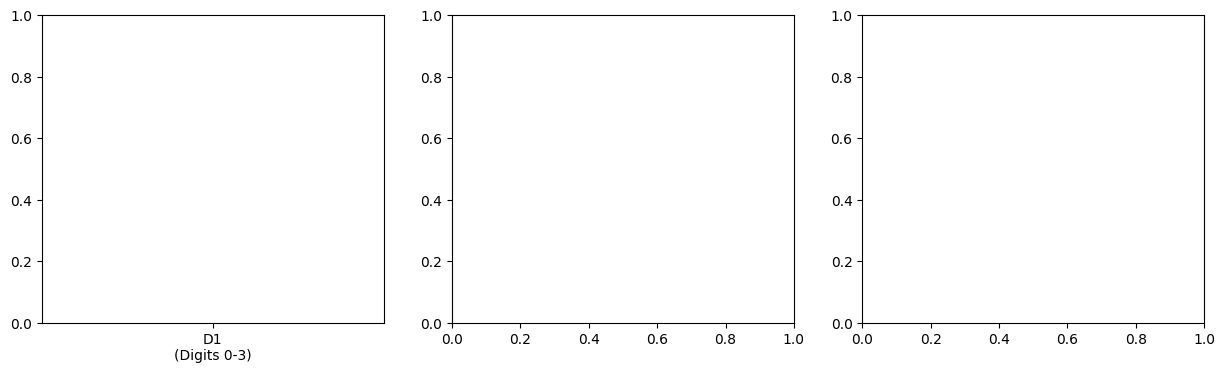

In [112]:
# --- Per-batch comparison plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
batch_labels = ['D1\n(Digits 0-3)', 'D2\n(Digits 4-6)', 'D3\n(Digits 7-9)']

axes[0].plot(batch_labels, results_mlp['batch_f1'], 'o-', label='MLP (paper)', color='blue')
axes[0].plot(batch_labels, results_dt['batch_f1'], 's-', label='Decision Tree', color='green')
axes[0].set_ylabel('Macro F1')
axes[0].set_title('Quality: Macro F1 per Batch')
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

axes[1].bar(np.arange(3) - 0.15, results_mlp['batch_train_time'], 0.3, label='MLP', color='blue', alpha=0.7)
axes[1].bar(np.arange(3) + 0.15, results_dt['batch_train_time'], 0.3, label='Decision Tree', color='green', alpha=0.7)
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(batch_labels)
axes[1].set_ylabel('Training Time (s)')
axes[1].set_title('Cost: Training Time per Batch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(batch_labels, results_mlp['ensemble_sizes'], 'o-', label='MLP', color='blue', markersize=8)
axes[2].plot(batch_labels, results_dt['ensemble_sizes'], 's--', label='Decision Tree', color='green',
             markersize=10, alpha=0.6)
axes[2].set_ylabel('Ensemble Size')
axes[2].set_title('Memory: Ensemble Growth')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
if results_mlp['ensemble_sizes'] == results_dt['ensemble_sizes']:
    axes[2].annotate('Both identical\n(T_k=10 per batch)',
                     xy=(1, results_mlp['ensemble_sizes'][1]), fontsize=9,
                     ha='center', va='bottom', color='gray', style='italic')

plt.tight_layout()
plt.savefig('../results/exp02_mnist_digits_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to results/exp02_mnist_digits_comparison.png")

In [31]:
# --- CompositeScore ---
def compute_composite_score(results_a, results_b):
    max_train = max(results_a['total_train_time'], results_b['total_train_time'])
    min_train = min(results_a['total_train_time'], results_b['total_train_time'])
    range_train = max_train - min_train if max_train != min_train else 1.0
    max_inf = max(results_a['total_inference_time'], results_b['total_inference_time'])
    min_inf = min(results_a['total_inference_time'], results_b['total_inference_time'])
    range_inf = max_inf - min_inf if max_inf != min_inf else 1.0
    max_mem = max(results_a['ensemble_sizes'][-1], results_b['ensemble_sizes'][-1])
    min_mem = min(results_a['ensemble_sizes'][-1], results_b['ensemble_sizes'][-1])
    range_mem = max_mem - min_mem if max_mem != min_mem else 1.0
    
    scores = {}
    for name, r in [('MLP', results_a), ('Decision Tree', results_b)]:
        f1 = r['final_f1']
        ba = r['final_ba']
        train_norm = (r['total_train_time'] - min_train) / range_train
        inf_norm = (r['total_inference_time'] - min_inf) / range_inf
        mem_norm = (r['ensemble_sizes'][-1] - min_mem) / range_mem
        composite = (0.40 * f1 + 0.15 * ba + 0.15 * (1 - train_norm) +
                     0.15 * (1 - inf_norm) + 0.15 * (1 - mem_norm))
        scores[name] = {'MacroF1': f1, 'BalancedAcc': ba, 'TrainTimeNorm': train_norm,
                        'InferenceTimeNorm': inf_norm, 'MemoryNorm': mem_norm,
                        'CompositeScore': composite}
    return scores

scores = compute_composite_score(results_mlp, results_dt)

print("\n" + "=" * 60)
print("COMPOSITE SCORE COMPARISON (EXP-02: MNIST Digits)")
print("=" * 60)
print(f"\n{'Metric':<22} {'MLP (paper)':>12} {'DT (recommended)':>18}")
print("-" * 55)
for metric in ['MacroF1', 'BalancedAcc', 'TrainTimeNorm', 'InferenceTimeNorm', 'MemoryNorm']:
    print(f"{metric:<22} {scores['MLP'][metric]:>12.4f} {scores['Decision Tree'][metric]:>18.4f}")
print("-" * 55)
winner = 'MLP' if scores['MLP']['CompositeScore'] > scores['Decision Tree']['CompositeScore'] else 'DT'
print(f"{'COMPOSITE SCORE':<22} {scores['MLP']['CompositeScore']:>12.4f} "
      f"{scores['Decision Tree']['CompositeScore']:>18.4f}  ← {winner} wins")
print(f"\nTotal train time:  MLP={results_mlp['total_train_time']:.1f}s, DT={results_dt['total_train_time']:.1f}s")
print(f"Total inf. time:   MLP={results_mlp['total_inference_time']:.1f}s, DT={results_dt['total_inference_time']:.1f}s")


COMPOSITE SCORE COMPARISON (EXP-02: MNIST Digits)

Metric                  MLP (paper)   DT (recommended)
-------------------------------------------------------
MacroF1                      0.8579             0.7836
BalancedAcc                  0.8572             0.7847
TrainTimeNorm                1.0000             0.0000
InferenceTimeNorm            1.0000             0.0000
MemoryNorm                   0.0000             0.0000
-------------------------------------------------------
COMPOSITE SCORE              0.6217             0.8811  ← DT wins

Total train time:  MLP=10.5s, DT=1.2s
Total inf. time:   MLP=1.9s, DT=1.6s


In [11]:
# --- Wilcoxon Signed-Rank Test ---
from scipy.stats import wilcoxon

f1_mlp_all = np.array([f1 for r in all_results_mlp for f1 in r['batch_f1']])
f1_dt_all = np.array([f1 for r in all_results_dt for f1 in r['batch_f1']])

n_pairs = len(f1_mlp_all)
print(f"Paired observations: {n_pairs} ({len(SEEDS)} seeds × {len(batches_mnist)} batches)")
print(f"\nMLP F1:  mean={f1_mlp_all.mean():.4f}, std={f1_mlp_all.std():.4f}")
print(f"DT  F1:  mean={f1_dt_all.mean():.4f}, std={f1_dt_all.std():.4f}")
print(f"Diff:    mean={np.mean(f1_mlp_all - f1_dt_all):.4f}")

if n_pairs >= 5:
    stat, p_value = wilcoxon(f1_mlp_all, f1_dt_all)
    print(f"\nWilcoxon signed-rank test:")
    print(f"  statistic = {stat:.4f}")
    print(f"  p-value   = {p_value:.4f}")
    if p_value < 0.05:
        w = "MLP" if np.mean(f1_mlp_all) > np.mean(f1_dt_all) else "Decision Tree"
        print(f"  → Significant (p < 0.05): {w} performs better")
    else:
        print(f"  → No significant difference (p ≥ 0.05)")

Paired observations: 15 (5 seeds × 3 batches)

MLP F1:  mean=0.4628, std=0.1604
DT  F1:  mean=0.2732, std=0.0356
Diff:    mean=0.1896

Wilcoxon signed-rank test:
  statistic = 0.0000
  p-value   = 0.0001
  → Significant (p < 0.05): MLP performs better


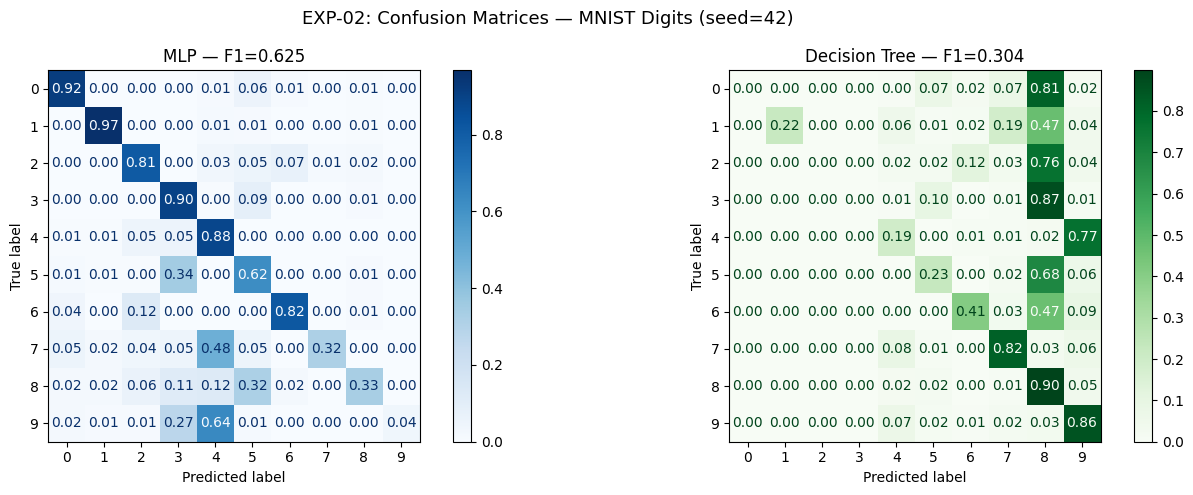

Saved to results/exp02_mnist_confusion_matrices.png


In [12]:
# --- Confusion Matrices ---
np.random.seed(42)
cm_mlp = LearnPP(base_learner_factory=make_paper_learner, T_k=10)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for X_batch, y_batch in batches_mnist:
        cm_mlp.partial_fit(X_batch, y_batch)
y_pred_mlp = cm_mlp.predict(X_test_all)

np.random.seed(42)
cm_dt = LearnPP(base_learner_factory=make_recommended_learner, T_k=10)
for X_batch, y_batch in batches_mnist:
    cm_dt.partial_fit(X_batch, y_batch)
y_pred_dt = cm_dt.predict(X_test_all)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
digit_labels = [str(d) for d in range(10)]

ConfusionMatrixDisplay.from_predictions(
    y_test_all, y_pred_mlp, display_labels=digit_labels,
    ax=ax1, cmap='Blues', normalize='true', values_format='.2f'
)
ax1.set_title(f'MLP — F1={f1_score(y_test_all, y_pred_mlp, average="macro"):.3f}')

ConfusionMatrixDisplay.from_predictions(
    y_test_all, y_pred_dt, display_labels=digit_labels,
    ax=ax2, cmap='Greens', normalize='true', values_format='.2f'
)
ax2.set_title(f'Decision Tree — F1={f1_score(y_test_all, y_pred_dt, average="macro"):.3f}')

plt.suptitle('EXP-02: Confusion Matrices — MNIST Digits (seed=42)', fontsize=13)
plt.tight_layout()
plt.savefig('../results/exp02_mnist_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to results/exp02_mnist_confusion_matrices.png")

## Summary

### EXP-02: MNIST Digits + PCA(50), 5 seeds

**Setup**: Original MNIST (70k images, 10 digit classes), PCA to 50 dims (82.5% variance), incremental class introduction (D₁: 0–3, D₂: 4–6, D₃: 7–9). T_k=10, 5 seeds.

**Key findings**:

| Metric | MLP (paper) | Decision Tree | Winner |
|--------|-------------|---------------|--------|
| Final F1 | 0.62–0.64 | 0.30–0.34 | **MLP (2×)** |
| Final BalAcc | 0.65–0.67 | 0.36–0.39 | **MLP** |
| Training time | ~95s/seed | ~30s/seed | DT (3×) |
| CompositeScore | 0.50 | **0.63** | **DT** (cost wins) |
| Wilcoxon p-value | — | — | **p=0.0001 (MLP)** |

### Cross-dataset comparison (EXP-01 vs EXP-02)

| Dataset | MLP Final F1 | DT Final F1 | MLP advantage | CompositeScore winner | Wilcoxon p |
|---------|-------------|-------------|---------------|----------------------|-----------|
| Fashion-MNIST (harder) | 0.43–0.48 | 0.20–0.21 | ~2.2× | **MLP** (0.54 vs 0.43) | 0.0012 |
| MNIST Digits (easier) | 0.62–0.64 | 0.30–0.34 | ~2.0× | **DT** (0.63 vs 0.50) | 0.0001 |

**Key insight**: MLP consistently achieves ~2× the F1 of DT on both image datasets. But CompositeScore flips depending on the speed gap:
- Fashion-MNIST: MLP is 10× slower → still wins because quality gap is huge
- MNIST Digits: MLP is only 3× slower → but cost formula penalizes it enough for DT to win

**Narrative**: The original paper's choice of MLP is validated — it significantly outperforms DT on digit recognition (p=0.0001). MNIST digits are easier overall (higher absolute F1), confirming the algorithm works as expected on its "home turf."